In [1]:
import pandas as pd

df = pd.read_csv("Diseases_and_Symptoms_dataset.csv")
print(df.shape)
df.head()

(96088, 231)


,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,sneezing,leg weakness,hysterical behavior,arm lump or mass,bleeding gums,pain in gums,diaper rash,hesitancy,back stiffness or tightness,low urine output
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [2]:
print(df.columns.tolist())

['diseases', 'anxiety and nervousness', 'depression', 'shortness of breath', 'depressive or psychotic symptoms', 'sharp chest pain', 'dizziness', 'insomnia', 'abnormal involuntary movements', 'chest tightness', 'palpitations', 'irregular heartbeat', 'breathing fast', 'hoarse voice', 'sore throat', 'difficulty speaking', 'cough', 'nasal congestion', 'throat swelling', 'diminished hearing', 'difficulty in swallowing', 'skin swelling', 'retention of urine', 'leg pain', 'hip pain', 'suprapubic pain', 'blood in stool', 'lack of growth', 'symptoms of the scrotum and testes', 'swelling of scrotum', 'pain in testicles', 'pus draining from ear', 'jaundice', 'white discharge from eye', 'irritable infant', 'abusing alcohol', 'fainting', 'hostile behavior', 'drug abuse', 'sharp abdominal pain', 'feeling ill', 'vomiting', 'headache', 'nausea', 'diarrhea', 'vaginal itching', 'painful urination', 'involuntary urination', 'pain during intercourse', 'frequent urination', 'lower abdominal pain', 'vagina

In [3]:
df.info()
df.describe(include='all').T
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96088 entries, 0 to 96087
Columns: 231 entries, diseases to low urine output
dtypes: int64(230), object(1)
memory usage: 169.3+ MB


diseases                            0
anxiety and nervousness             0
depression                          0
shortness of breath                 0
depressive or psychotic symptoms    0
                                   ..
pain in gums                        0
diaper rash                         0
hesitancy                           0
back stiffness or tightness         0
low urine output                    0
Length: 231, dtype: int64

In [4]:
disease_col = [c for c in df.columns if 'disease' in c.lower()][0]
print("Target column:", disease_col)
print("Number of unique diseases:", df[disease_col].nunique())
print("Disease names:", df[disease_col].unique())

Target column: diseases
Number of unique diseases: 100
Disease names: ['panic disorder' 'vaginitis' 'problem during pregnancy'
 'acute pancreatitis' 'asthma' 'infectious gastroenteritis'
 'acute sinusitis' 'cornea infection' 'marijuana abuse' 'bursitis'
 'actinic keratosis' 'chronic obstructive pulmonary disease (copd)'
 'spondylosis' 'injury to the arm' 'complex regional pain syndrome'
 'injury to the trunk' 'vulvodynia' 'concussion' 'hypoglycemia'
 'hiatal hernia' 'allergy' 'acute bronchospasm'
 'degenerative disc disease' 'pain after an operation' 'injury to the leg'
 'gout' 'otitis media' 'acute kidney injury' 'threatened pregnancy'
 'gum disease' 'gastrointestinal hemorrhage' 'anxiety'
 'conjunctivitis due to allergy' 'drug reaction' 'macular degeneration'
 'pneumonia' 'vaginal cyst' 'carpal tunnel syndrome' 'nose disorder'
 'dental caries' 'hypertensive heart disease'
 'seasonal allergies (hay fever)' 'fungal infection of the hair'
 'rectal disorder' 'stye' 'heart attack' 'obstru

In [6]:
# Count the number of occurrences of each disease
disease_counts = df['diseases'].value_counts()
# Top 10 most frequent diseases (sorted increasing)
top_10 = disease_counts.nlargest(10).sort_values()
print("=== Top 10 Most Frequent Diseases (Increasing Count) ===")
print(top_10)

# Top 10 least frequent diseases (sorted increasing)
least_10 = disease_counts.nsmallest(10).sort_values()
print("\n=== Top 10 Least Frequent Diseases (Increasing Count) ===")
print(least_10)

=== Top 10 Most Frequent Diseases (Increasing Count) ===
diseases
conjunctivitis due to allergy     1215
peripheral nerve disorder         1215
vaginal cyst                      1215
esophagitis                       1215
hypoglycemia                      1215
spondylosis                       1216
complex regional pain syndrome    1217
vulvodynia                        1218
nose disorder                     1218
cystitis                          1219
Name: count, dtype: int64

=== Top 10 Least Frequent Diseases (Increasing Count) ===
diseases
gum disease                           803
allergy                               803
injury to the trunk                   803
temporary or benign blood in urine    803
pelvic inflammatory disease           804
hypertensive heart disease            804
skin pigmentation disorder            805
chronic back pain                     805
idiopathic painful menstruation       805
pain after an operation               806
Name: count, dtype: int64


In [7]:
symptom_cols = [c for c in df.columns if c != disease_col]
print("Number of symptom columns:", len(symptom_cols))
print("Symptoms:", symptom_cols)

Number of symptom columns: 230
Symptoms: ['anxiety and nervousness', 'depression', 'shortness of breath', 'depressive or psychotic symptoms', 'sharp chest pain', 'dizziness', 'insomnia', 'abnormal involuntary movements', 'chest tightness', 'palpitations', 'irregular heartbeat', 'breathing fast', 'hoarse voice', 'sore throat', 'difficulty speaking', 'cough', 'nasal congestion', 'throat swelling', 'diminished hearing', 'difficulty in swallowing', 'skin swelling', 'retention of urine', 'leg pain', 'hip pain', 'suprapubic pain', 'blood in stool', 'lack of growth', 'symptoms of the scrotum and testes', 'swelling of scrotum', 'pain in testicles', 'pus draining from ear', 'jaundice', 'white discharge from eye', 'irritable infant', 'abusing alcohol', 'fainting', 'hostile behavior', 'drug abuse', 'sharp abdominal pain', 'feeling ill', 'vomiting', 'headache', 'nausea', 'diarrhea', 'vaginal itching', 'painful urination', 'involuntary urination', 'pain during intercourse', 'frequent urination', 'l

sharp abdominal pain    15217
vomiting                14206
back pain               12628
nausea                  11942
cough                   11220
fever                   10641
sharp chest pain         9444
shortness of breath      9377
headache                 9241
nasal congestion         8775
dtype: int64


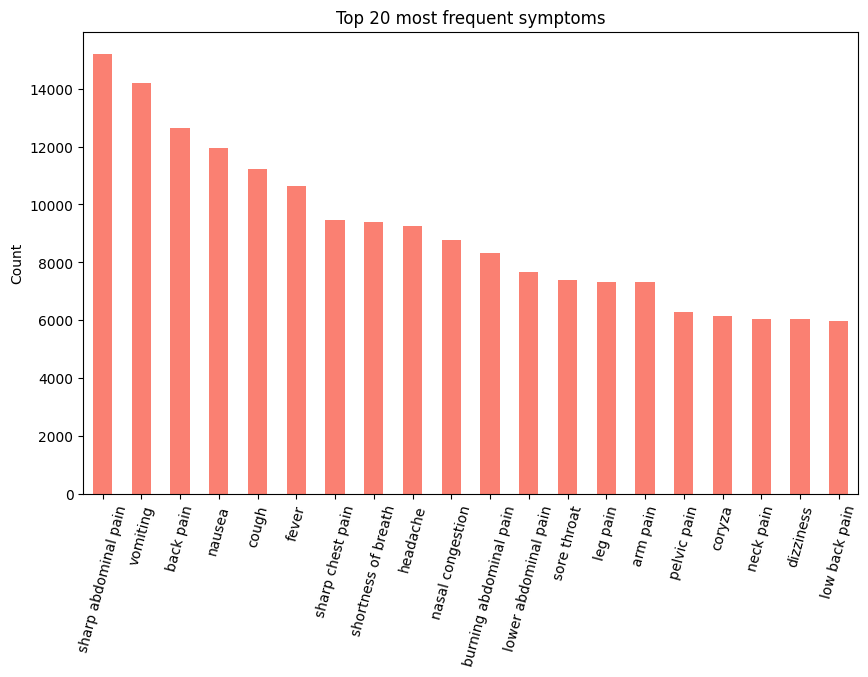

In [8]:
import matplotlib.pyplot as plt
symptom_counts = df[symptom_cols].sum().sort_values(ascending=False)
print(symptom_counts.head(10))

plt.figure(figsize=(10,6))
symptom_counts.head(20).plot(kind='bar', color='salmon')
plt.title('Top 20 most frequent symptoms')
plt.ylabel('Count')
plt.xticks(rotation=75)
plt.show()


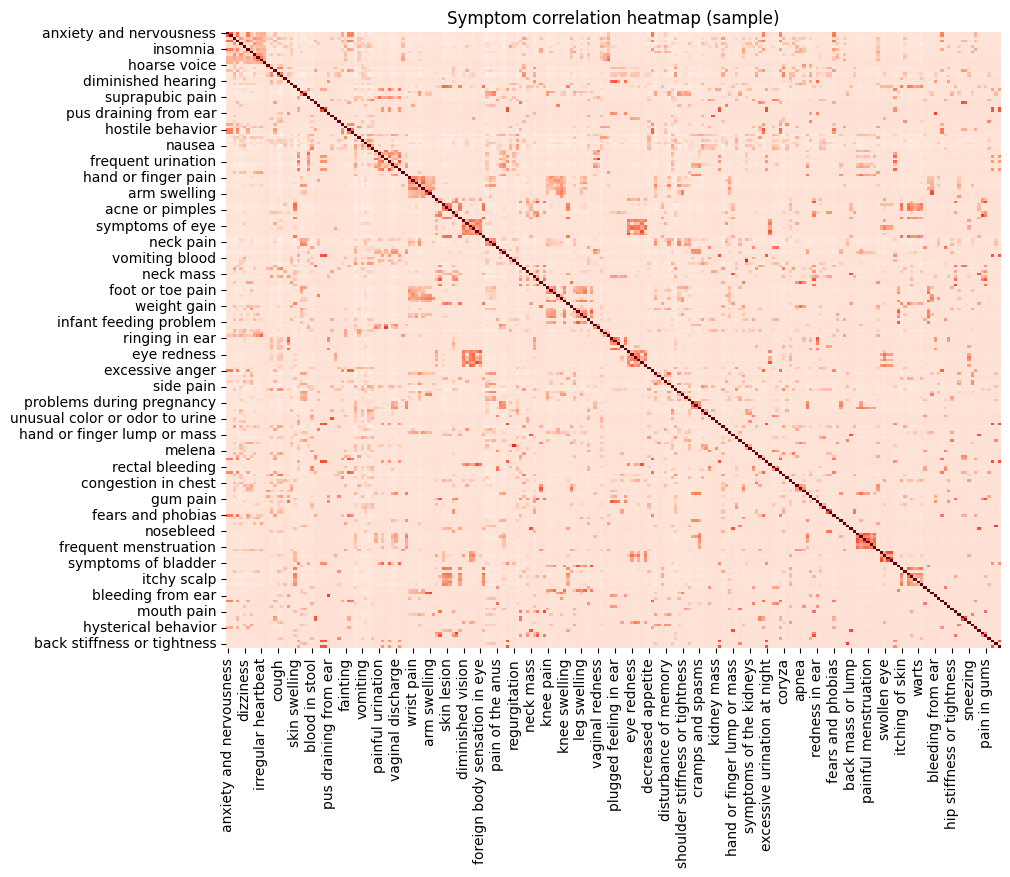

In [9]:
import seaborn as sns

corr = df[symptom_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='Reds', cbar=False)
plt.title('Symptom correlation heatmap (sample)')
plt.show()

In [10]:
missing = df.isna().sum()
constant = [c for c in df.columns if df[c].nunique() == 1]

print("Missing columns:\n", missing[missing > 0])
print("Constant columns:", constant)

Missing columns:
 Series([], dtype: int64)
Constant columns: []


In [11]:
df_clean = df.dropna(subset=[disease_col])  # remove rows without disease (dans notre cas n'existe pas)
df_clean = df_clean.drop(columns=constant)  # drop constant columns(dans notre cas n'existe pas)
print(df_clean.shape)

(96088, 231)


In [12]:
num_diseases = df_clean[disease_col].nunique()
num_symptoms = len([c for c in df_clean.columns if c != disease_col])
num_rows = len(df_clean)

print(f"Total records: {num_rows}")
print(f"Total unique diseases: {num_diseases}")
print(f"Total symptom features: {num_symptoms}")
print(f"Average symptoms per disease: {df_clean[symptom_cols].sum(axis=1).mean():.2f}")


Total records: 96088
Total unique diseases: 100
Total symptom features: 230
Average symptoms per disease: 5.87


| Domain                             | Count (dataset) | Example diseases                                               |
| ---------------------------------- | --------------- | -------------------------------------------------------------- |
| Musculoskeletal / Trauma           | 10              | spondylosis, bursitis, sprain, herniated disk                  |
| Respiratory / Infectious           | 10              | asthma, COPD, pneumonia, croup, common cold                    |
| Gastrointestinal / Infectious      | 15              | pancreatitis, gastroenteritis, appendicitis, hemorrhoids       |
| Genitourinary / Reproductive       | 15              | vaginitis, cystitis, uterine issues, pregnancy issues          |
| Cardiovascular                     | 5               | heart attack, heart failure, angina, hypertension              |
| Dermatology / Skin                 | 12              | psoriasis, eczema, actinic keratosis, skin infections          |
| ENT / Eye / Oral                   | 12              | sinusitis, otitis media, conjunctivitis, stye                  |
| Neurological / CNS                 | 7               | multiple sclerosis, concussion, peripheral nerve disorder      |
| Psychiatric / Mental health        | 6               | anxiety, depression, schizophrenia, personality disorder       |
| Infectious / Immunology            | 8               | sepsis, allergies, drug reaction, infections                   |
| Hematology / Endocrine / Metabolic | 2               | sickle cell crisis, hypoglycemia                               |
| Other / Miscellaneous              | 6               | pregnancy complications, substance abuse, pain after operation |


| Disease                                      | Domain                               |
| -------------------------------------------- | ------------------------------------ |
| panic disorder                               | Psychiatric / Mental health          |
| vaginitis                                    | Genitourinary / Reproductive         |
| problem during pregnancy                     | Other / Miscellaneous                |
| acute pancreatitis                           | Gastrointestinal                     |
| asthma                                       | Respiratory                          |
| infectious gastroenteritis                   | Gastrointestinal / Infectious        |
| acute sinusitis                              | ENT / Infectious                     |
| cornea infection                             | ENT / Eye / Infectious               |
| marijuana abuse                              | Other / Substance abuse              |
| bursitis                                     | Musculoskeletal                      |
| actinic keratosis                            | Dermatology / Skin                   |
| chronic obstructive pulmonary disease (COPD) | Respiratory                          |
| spondylosis                                  | Musculoskeletal                      |
| injury to the arm                            | Musculoskeletal / Trauma             |
| complex regional pain syndrome               | Musculoskeletal / Neurological       |
| injury to the trunk                          | Musculoskeletal / Trauma             |
| vulvodynia                                   | Genitourinary / Reproductive         |
| concussion                                   | Neurological / CNS / Trauma          |
| hypoglycemia                                 | Hematology / Endocrine / Metabolic   |
| hiatal hernia                                | Gastrointestinal                     |
| allergy                                      | Infectious / Immunology              |
| acute bronchospasm                           | Respiratory                          |
| degenerative disc disease                    | Musculoskeletal                      |
| pain after an operation                      | Musculoskeletal / Other / Trauma     |
| injury to the leg                            | Musculoskeletal / Trauma             |
| gout                                         | Musculoskeletal / Metabolic          |
| otitis media                                 | ENT / Infectious                     |
| acute kidney injury                          | Genitourinary / Reproductive / Renal |
| threatened pregnancy                         | Other / Miscellaneous                |
| gum disease                                  | ENT / Oral                           |
| gastrointestinal hemorrhage                  | Gastrointestinal                     |
| anxiety                                      | Psychiatric / Mental health          |
| conjunctivitis due to allergy                | ENT / Eye / Immunology               |
| drug reaction                                | Infectious / Immunology / Other      |
| macular degeneration                         | ENT / Eye                            |
| pneumonia                                    | Respiratory / Infectious             |
| vaginal cyst                                 | Genitourinary / Reproductive         |
| carpal tunnel syndrome                       | Musculoskeletal / Neurological       |
| nose disorder                                | ENT                                  |
| dental caries                                | ENT / Oral                           |
| hypertensive heart disease                   | Cardiovascular                       |
| seasonal allergies (hay fever)               | Infectious / Immunology              |
| fungal infection of the hair                 | Dermatology / Skin / Infectious      |
| rectal disorder                              | Gastrointestinal                     |
| stye                                         | ENT / Eye                            |
| heart attack                                 | Cardiovascular                       |
| obstructive sleep apnea (OSA)                | Respiratory                          |
| psoriasis                                    | Dermatology / Skin                   |
| arthritis of the hip                         | Musculoskeletal                      |
| sickle cell crisis                           | Hematology / Blood / Metabolic       |
| otitis externa (swimmer's ear)               | ENT / Infectious                     |
| acute bronchiolitis                          | Respiratory / Infectious             |
| pyogenic skin infection                      | Dermatology / Skin / Infectious      |
| noninfectious gastroenteritis                | Gastrointestinal                     |
| benign prostatic hyperplasia (BPH)           | Genitourinary / Reproductive         |
| spinal stenosis                              | Musculoskeletal / Neurological       |
| acute bronchitis                             | Respiratory / Infectious             |
| croup                                        | Respiratory / Infectious             |
| idiopathic excessive menstruation            | Genitourinary / Reproductive         |
| ear drum damage                              | ENT / Trauma                         |
| temporary or benign blood in urine           | Genitourinary / Reproductive         |
| common cold                                  | Respiratory / Infectious             |
| depression                                   | Psychiatric / Mental health          |
| idiopathic irregular menstrual cycle         | Genitourinary / Reproductive         |
| schizophrenia                                | Psychiatric / Mental health          |
| sepsis                                       | Infectious / Systemic                |
| cholecystitis                                | Gastrointestinal / Infectious        |
| cystitis                                     | Genitourinary / Infectious           |
| hemorrhoids                                  | Gastrointestinal                     |
| contact dermatitis                           | Dermatology / Skin                   |
| sinus bradycardia                            | Cardiovascular                       |
| pelvic inflammatory disease                  | Genitourinary / Infectious           |
| liver disease                                | Gastrointestinal                     |
| chronic constipation                         | Gastrointestinal                     |
| skin polyp                                   | Dermatology / Skin                   |
| brachial neuritis                            | Neurological / Musculoskeletal       |
| esophagitis                                  | Gastrointestinal                     |
| diverticulitis                               | Gastrointestinal / Infectious        |
| sprain or strain                             | Musculoskeletal / Trauma             |
| idiopathic painful menstruation              | Genitourinary / Reproductive         |
| eustachian tube dysfunction (ear disorder)   | ENT                                  |
| appendicitis                                 | Gastrointestinal / Infectious        |
| hyperemesis gravidarum                       | Other / Miscellaneous                |
| urinary tract infection                      | Genitourinary / Infectious           |
| peripheral nerve disorder                    | Neurological / CNS                   |
| sebaceous cyst                               | Dermatology / Skin                   |
| spontaneous abortion                         | Other / Miscellaneous                |
| gallstone                                    | Gastrointestinal                     |
| multiple sclerosis                           | Neurological / CNS                   |
| angina                                       | Cardiovascular                       |
| skin pigmentation disorder                   | Dermatology / Skin                   |
| personality disorder                         | Psychiatric / Mental health          |
| strep throat                                 | ENT / Infectious                     |
| developmental disability                     | Neurological / CNS / Psychiatric     |
| chronic back pain                            | Musculoskeletal                      |
| heart failure                                | Cardiovascular                       |
| conjunctivitis                               | ENT / Eye                            |
| herniated disk                               | Musculoskeletal / Neurological       |
| diaper rash                                  | Dermatology / Skin                   |
| eczema                                       | Dermatology / Skin                   |
